<a href="https://colab.research.google.com/github/abhishekanand04/Probability-and-Stats/blob/feature%2Fupdate/Nov24_PD_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from scipy.stats import norm

In [ ]:
!wget --no-check-certificate https://drive.google.com/uc?id=1Mrt008vkE4nVb1zE4f06_rtq70QPfkIo -O weight-height.csv

--2024-12-06 15:04:42--  https://drive.google.com/uc?id=1Mrt008vkE4nVb1zE4f06_rtq70QPfkIo
Resolving drive.google.com (drive.google.com)... 173.194.216.102, 173.194.216.138, 173.194.216.113, ...
Connecting to drive.google.com (drive.google.com)|173.194.216.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1Mrt008vkE4nVb1zE4f06_rtq70QPfkIo [following]
--2024-12-06 15:04:42--  https://drive.usercontent.google.com/download?id=1Mrt008vkE4nVb1zE4f06_rtq70QPfkIo
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.251.107.132, 2607:f8b0:400c:c32::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.251.107.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 428120 (418K) [application/octet-stream]
Saving to: ‘weight-height.csv’

weight-height.csv   100%[===================>] 418.09K  --.-KB/s    in 0.004s  

2024-12-06 15:04:44 (11

In [ ]:
df_hw = pd.read_csv("weight-height.csv")
df_hw.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [ ]:
df_height = df_hw["Height"]
df_height.head()

,Height
0,73.847017
1,68.781904
2,74.110105
3,71.730978
4,69.881796


<Axes: xlabel='Height', ylabel='Count'>

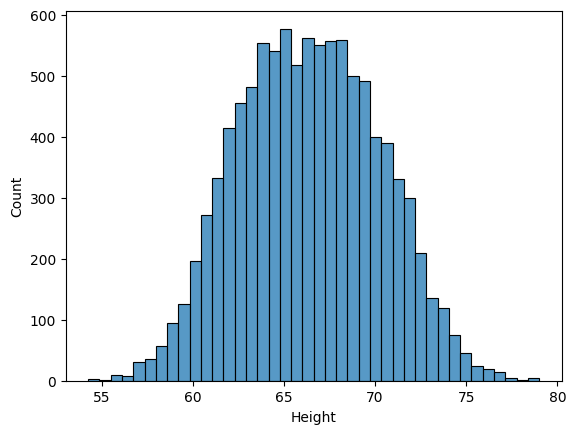

In [ ]:
sns.histplot(df_height, bins = 40)

<Axes: xlabel='Height', ylabel='Count'>

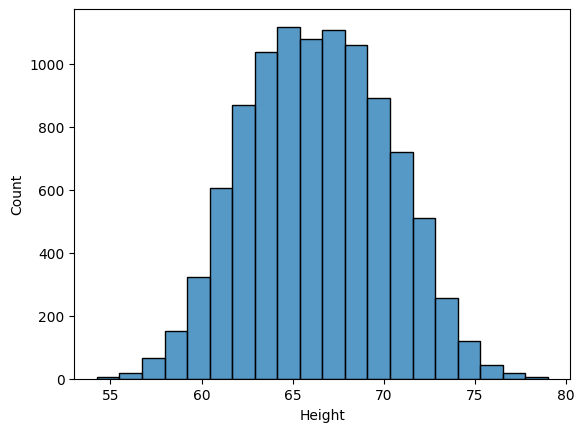

In [ ]:
sns.histplot(df_height, bins = 20)

In [ ]:
z = (69.1 - 65) / 2.5
z

1.6399999999999977

In [ ]:
# calculate fraction who are shorter than 69.1
norm.cdf(z)

0.949497416525896

In [ ]:
norm.cdf(1) - norm.cdf(-1)

0.6826894921370859

In [ ]:
norm.cdf(2) - norm.cdf(-2)

0.9544997361036416

In [ ]:
norm.cdf(3) - norm.cdf(-3)

0.9973002039367398

In [ ]:
# Balls produced by the manufacturer have a mean diameter of 50 mm and std dev 2 mm.
# What fraction of balls have a diameter smaller than 53 mm?
x = 53
mean = 50
sd = 2

z = (x - mean) / sd
z

1.5

In [ ]:
norm.cdf(1.5)

0.9331927987311419

In [ ]:
# The height of people is Gaussian with mean 65 inches and standard deviation 2.5 inches.
# One person says:  96% people are shorter than me. What is my height?

# x = mean + z * sd

# This inverse method of finding the z-score from given percent/fraction is termed as the Percent Point Function (PPF).

In [ ]:
# what is the height such that 96% people are shorter?
z = norm.ppf(0.96)
z

1.7506860712521692

In [ ]:
mean = 65
sd = 2.5
x = mean + z * sd
x

69.37671517813042

In [ ]:
norm.cdf(norm.ppf(0.7))

0.7

In [ ]:
# Now let's solve a Microsoft Interview question

# Skaters take a mean of 7.42 seconds and std dev of 0.34 seconds for 500 meters.
# What should his speed be such that he is faster than 95% of his competitors?

mean = 7.42
sd = 0.34

# If speed is > 95% of competitors => time is < 95% of competitors.
# => 5% of competitors have take < that this time (x)
z = norm.ppf(0.05)
z

-1.6448536269514729

In [ ]:
x = mean + z * sd
x

6.860749766836499

In [ ]:
distance = 500
time = x
speed = distance / time
speed

72.87833210546471

In [ ]:
# A retail outlet sells around 1000 toothpastes a week, with std dev = 200.
# If we have 1300 stock units as our inventory, then what is the probability
# you'd need to replenish stocks within the week?

mean = 1000
sd = 200
x = 1300

# P(x > 1300) = ?
# P(x < 1300) -> easy to find

z = (x - mean) / sd
norm.cdf(z)

0.9331927987311419

In [ ]:
1 - norm.cdf(z)

0.06680720126885809

In [ ]:
# How much inventory should you have, such that there is only a 3% chance of running out of stock mid-week?

# P(x > ?) = 0.03

norm.ppf(0.97)

1.8807936081512509

In [ ]:
x = mean + norm.ppf(0.97) * sd
x

1376.15872163025

In [ ]:
# Standard Normal Distribution (also called the z-distribution)
# mean = 0, sd = 1

# We can take any Normal Distribution and convert it to The Standard Normal Distribution, using Standardization.

In [ ]:
# Imagine you have two friends,
# Alex and Taylor, who are both great at math but have different grading systems.
# Alex's math scores range from 0 to 100, while Taylor's scores range from 0 to 50.
# You want to know who is performing with more consistency.

In [ ]:
# Standardization looks at how each person's score compares to the average (mean) score in their respective classes.

# Alex's math scores
alex_scores = np.array([90, 75, 80, 95, 60])

# Taylor's math scores
taylor_scores = np.array([40, 35, 45, 30, 50])

In [ ]:
alex_mu = np.mean(alex_scores)
taylor_mu = np.mean(taylor_scores)

alex_sigma = np.std(alex_scores)
taylor_sigma = np.std(taylor_scores)

alex_mu, taylor_mu, alex_sigma, taylor_sigma

(80.0, 40.0, 12.24744871391589, 7.0710678118654755)

In [ ]:
# Standardize the scores -> (x - mu) / sigma
alex_standardized = (alex_scores - alex_mu) / alex_sigma
taylor_standardized = (taylor_scores - taylor_mu) / taylor_sigma

print("Standardized Scores for Alex:", np.round(alex_standardized, 2))
print("Standardized Scores for Taylor:", np.round(taylor_standardized, 2))

Standardized Scores for Alex: [ 0.82 -0.41  0.    1.22 -1.63]
Standardized Scores for Taylor: [ 0.   -0.71  0.71 -1.41  1.41]


In [ ]:
1.22 - (-1.63)

2.8499999999999996

In [ ]:
1.41 - (-1.41)

2.82

In [ ]:
# So, we can say that Taylor's performance is more consistent compared to Alex.